# 01: Data Loading and Classification

This notebook handles:
- Loading the LLPS protein dataset
- Classifying proteins by pLLPS threshold
- Identifying membrane proteins
- Saving results for downstream analysis

**Outputs:**
- `results/full_dataset.csv` - Complete dataset with classifications
- `results/high_pllps_proteins.csv` - High pLLPS proteins (≥0.7)
- `results/membrane_proteins.csv` - Membrane proteins
- `results/classification_summary.json` - Summary statistics

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import llps_functions as lf

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Dataset

In [2]:
# Load the LLPS dataset
df = lf.load_llps_data('Human Phase separation data.xlsx')
print(f"\n📊 Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

✅ Loaded 20366 proteins from Human Phase separation data.xlsx
   p(LLPS) range: 0.060 - 1.000

📊 Dataset shape: (20366, 11)

Columns: ['Entry', 'Entry name', 'Protein names', 'p(LLPS)', 'n(DPR=> 25)', 'Organism', 'Length', 'Function [CC]', 'Subcellular location [CC]', 'Involvement in disease', 'Cross-reference (PDB)']


In [3]:
# Display first few rows
df.head()

,Entry,Entry name,Protein names,p(LLPS),n(DPR=> 25),Organism,Length,Function [CC],Subcellular location [CC],Involvement in disease,Cross-reference (PDB)
0,Q9Y6V0,PCLO_HUMAN,Protein piccolo (Aczonin),1.0,21,Homo sapiens (Human),5142.0,Scaffold protein of the presynaptic cytomatri...,"Cell junction, synapse, presynaptic active zo...",Pontocerebellar hypoplasia 3 (PCH3) [MIM:6080...,1UJD;
1,Q9Y566,SHAN1_HUMAN,SH3 and multiple ankyrin repeat domains protei...,1.0,8,Homo sapiens (Human),2161.0,Seems to be an adapter protein in the postsyn...,"Cytoplasm {ECO:0000250}. Cell junction, synap...",NaN,6CPI;
2,Q9Y520,PRC2C_HUMAN,Protein PRRC2C (BAT2 domain-containing protein...,1.0,17,Homo sapiens (Human),2896.0,Required for efficient formation of stress gr...,"Cytoplasm, Stress granule {ECO:0000305|PubMed...",NaN,NaN
3,Q9Y4H2,IRS2_HUMAN,Insulin receptor substrate 2 (IRS-2),1.0,9,Homo sapiens (Human),1338.0,May mediate the control of various cellular p...,"Cytoplasm, cytosol {ECO:0000250}.",NaN,3FQW;3FQX;
4,Q9Y3S1,WNK2_HUMAN,Serine/threonine-protein kinase WNK2 (EC 2.7.1...,1.0,18,Homo sapiens (Human),2297.0,Serine/threonine kinase which plays an import...,"Cytoplasm {ECO:0000269|PubMed:17667937, ECO:0...",NaN,6ELM;6FBK;


## 2. Classify Proteins by pLLPS Threshold

In [4]:
# Set classification thresholds
HIGH_THRESHOLD = 0.7
LOW_THRESHOLD = 0.4

# Classify proteins
df_classified, high_pllps_ids = lf.get_high_pllps_proteins(
    df, 
    threshold=HIGH_THRESHOLD
)

print(f"\n✅ Classification complete:")
print(f"   High pLLPS (≥{HIGH_THRESHOLD}): {len(high_pllps_ids)} proteins")
print(f"   Percentage: {len(high_pllps_ids)/len(df)*100:.1f}%")


📊 pLLPS Classification (threshold = 0.7):
   High pLLPS: 6657 proteins (32.7%)
   Low pLLPS:  13709 proteins (67.3%)

✅ Classification complete:
   High pLLPS (≥0.7): 6657 proteins
   Percentage: 32.7%


In [5]:
# Add classification column
def classify_pllps(score):
    if pd.isna(score):
        return 'Unknown'
    elif score >= HIGH_THRESHOLD:
        return 'High'
    elif score <= LOW_THRESHOLD:
        return 'Low'
    else:
        return 'Medium'

df_classified['pLLPS_Class'] = df_classified['p(LLPS)'].apply(classify_pllps)

# Show class distribution
print("\n📊 pLLPS Class Distribution:")
print(df_classified['pLLPS_Class'].value_counts())
print(f"\nPercentages:")
print(df_classified['pLLPS_Class'].value_counts(normalize=True) * 100)


📊 pLLPS Class Distribution:
pLLPS_Class
Low       10797
High       6657
Medium     2912
Name: count, dtype: int64

Percentages:
pLLPS_Class
Low       53.014829
High      32.686831
Medium    14.298340
Name: proportion, dtype: float64


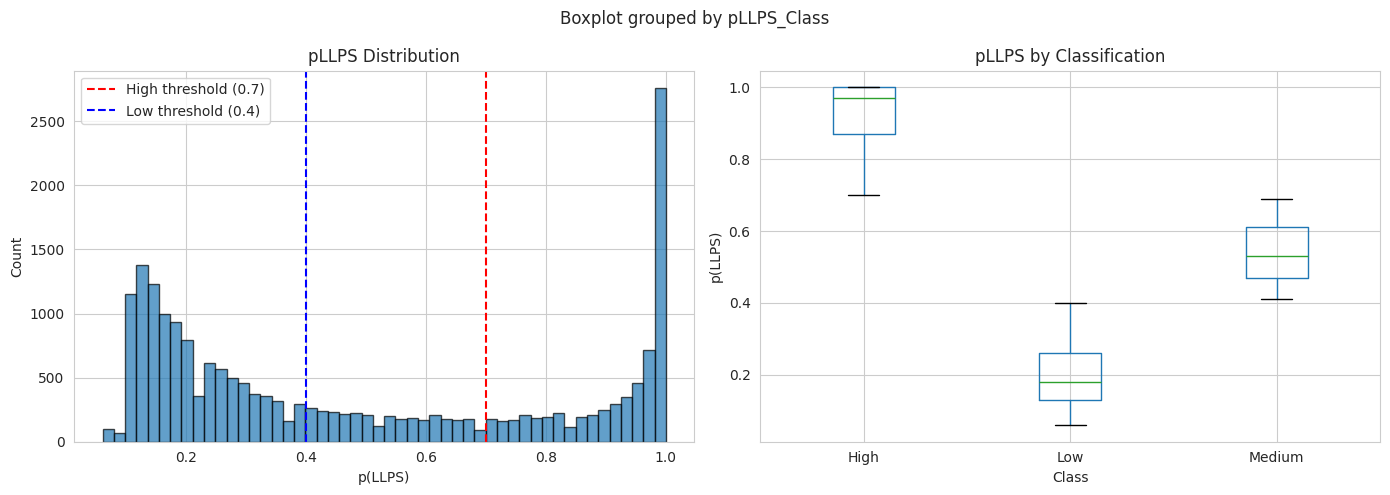


✅ Saved plot: results/pllps_distribution.png


In [6]:
# Visualize pLLPS distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_classified['p(LLPS)'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(HIGH_THRESHOLD, color='red', linestyle='--', label=f'High threshold ({HIGH_THRESHOLD})')
axes[0].axvline(LOW_THRESHOLD, color='blue', linestyle='--', label=f'Low threshold ({LOW_THRESHOLD})')
axes[0].set_xlabel('p(LLPS)')
axes[0].set_ylabel('Count')
axes[0].set_title('pLLPS Distribution')
axes[0].legend()

# Box plot by class
df_classified.boxplot(column='p(LLPS)', by='pLLPS_Class', ax=axes[1])
axes[1].set_title('pLLPS by Classification')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('p(LLPS)')

plt.tight_layout()
plt.savefig('results/pllps_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Saved plot: results/pllps_distribution.png")

## 3. Identify Membrane Proteins

In [7]:
# Filter to membrane proteins
membrane_df = lf.filter_membrane_proteins(df_classified)

print(f"\n📊 Membrane protein statistics:")
print(f"   Total membrane proteins: {len(membrane_df)}")
print(f"   High pLLPS membrane proteins: {(membrane_df['pLLPS_Class'] == 'High').sum()}")
print(f"   Medium pLLPS membrane proteins: {(membrane_df['pLLPS_Class'] == 'Medium').sum()}")
print(f"   Low pLLPS membrane proteins: {(membrane_df['pLLPS_Class'] == 'Low').sum()}")

🔍 Filtered to 6463 membrane proteins (31.7%)

📊 Membrane protein statistics:
   Total membrane proteins: 6463
   High pLLPS membrane proteins: 1287
   Medium pLLPS membrane proteins: 872
   Low pLLPS membrane proteins: 4304


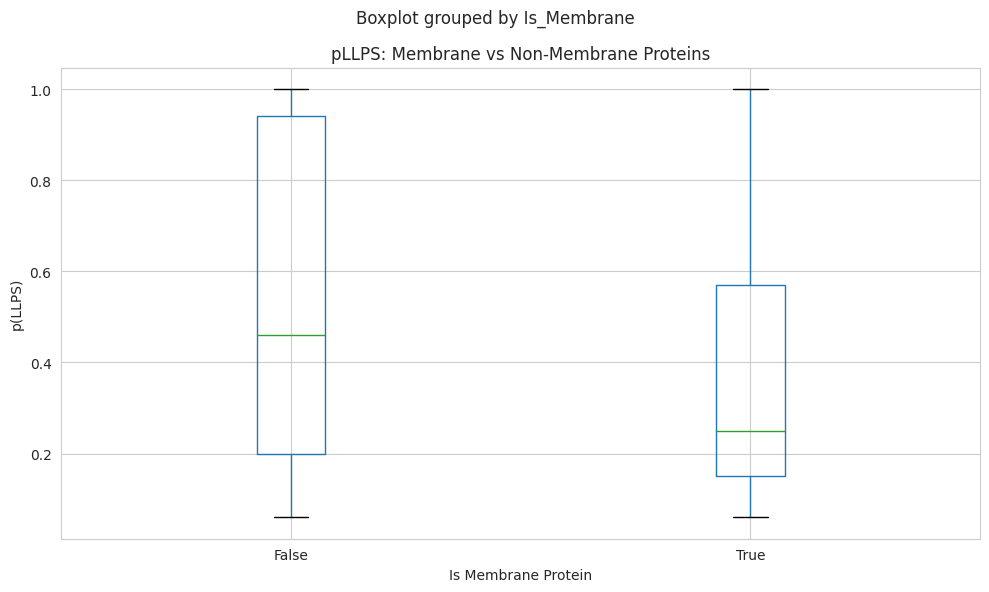


✅ Saved plot: results/membrane_vs_nonmembrane.png


In [8]:
# Membrane vs non-membrane pLLPS comparison
df_classified['Is_Membrane'] = df_classified['Entry'].isin(membrane_df['Entry'])

fig, ax = plt.subplots(figsize=(10, 6))
df_classified.boxplot(column='p(LLPS)', by='Is_Membrane', ax=ax)
ax.set_title('pLLPS: Membrane vs Non-Membrane Proteins')
ax.set_xlabel('Is Membrane Protein')
ax.set_ylabel('p(LLPS)')
plt.tight_layout()
plt.savefig('results/membrane_vs_nonmembrane.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Saved plot: results/membrane_vs_nonmembrane.png")

## 4. Save Results

In [9]:
# Save full classified dataset
lf.save_analysis_result(df_classified, 'full_dataset', format='csv')

# Save high pLLPS proteins
high_pllps_df = df_classified[df_classified['pLLPS_Class'] == 'High'].copy()
lf.save_analysis_result(high_pllps_df, 'high_pllps_proteins', format='csv')

# Save membrane proteins
lf.save_analysis_result(membrane_df, 'membrane_proteins', format='csv')

# Save summary statistics
summary = {
    'total_proteins': len(df_classified),
    'high_pllps_count': len(high_pllps_df),
    'high_pllps_percentage': len(high_pllps_df) / len(df_classified) * 100,
    'membrane_protein_count': len(membrane_df),
    'membrane_protein_percentage': len(membrane_df) / len(df_classified) * 100,
    'high_pllps_membrane_count': (membrane_df['pLLPS_Class'] == 'High').sum(),
    'thresholds': {
        'high': HIGH_THRESHOLD,
        'low': LOW_THRESHOLD
    },
    'class_distribution': df_classified['pLLPS_Class'].value_counts().to_dict()
}

lf.save_analysis_result(summary, 'classification_summary', format='json')

print("\n" + "="*60)
print("✅ All results saved successfully!")
print("="*60)

✅ Saved CSV to: results/full_dataset.csv
✅ Saved CSV to: results/high_pllps_proteins.csv
✅ Saved CSV to: results/membrane_proteins.csv
✅ Saved JSON to: results/classification_summary.json

✅ All results saved successfully!


In [10]:
# List saved files
lf.list_saved_results()

📁 Found 13 result files in results:
   - classification_summary.json (0.4 KB)
   - communities_analysis.csv (2.7 KB)
   - full_dataset.csv (18.7 MB)
   - functional_group_interactions.csv (0.4 KB)
   - functional_group_pllps_analysis.csv (0.3 KB)
   - high_pllps_clusters.csv (2.6 KB)
   - high_pllps_hubs.csv (16.0 KB)
   - high_pllps_proteins.csv (6.1 MB)
   - high_pllps_proteins_connectivity.csv (23.6 KB)
   - hub_analysis_full.csv (311.4 KB)
   - llps_driven_clusters.csv (0.2 KB)
   - membrane_proteins.csv (6.9 MB)
   - membrane_proteins_full.csv (9.9 MB)


['classification_summary.json',
 'communities_analysis.csv',
 'full_dataset.csv',
 'functional_group_interactions.csv',
 'functional_group_pllps_analysis.csv',
 'high_pllps_clusters.csv',
 'high_pllps_hubs.csv',
 'high_pllps_proteins.csv',
 'high_pllps_proteins_connectivity.csv',
 'hub_analysis_full.csv',
 'llps_driven_clusters.csv',
 'membrane_proteins.csv',
 'membrane_proteins_full.csv']

## Summary

✅ **Completed:**
1. Loaded LLPS dataset
2. Classified proteins into High/Medium/Low pLLPS categories
3. Identified membrane proteins
4. Generated visualizations
5. Saved all results to `results/` directory

**Next step:** Run `02_string_interactions.ipynb` to fetch protein-protein interactions from STRING database.